# How do GDP and healthcare spending affect child mortality rates across different countries?

**Healthcare Analytics — Midsemester Project · DIT 2B, Group 3 · July 2026**

**Data:** World Bank World Development Indicators (2000–2023, 196 countries) — GDP per capita (`NY.GDP.PCAP.CD`), current health expenditure % of GDP (`SH.XPD.CHEX.GD.ZS`), health expenditure per capita (`SH.XPD.CHEX.PC.CD`), under-5 mortality rate (`SH.DYN.MORT`).

Cleaning steps are documented in `methodology_log.md`; column definitions in `data_dictionary.md`. This notebook covers:
1. **Descriptive analysis** — aggregations and frequency distributions of child mortality by region and income group
2. **Predictive analysis** — Pearson & Spearman correlations (with log-transformed GDP), global time-series trend with a moving average
3. **Comparative analysis** — high-income vs low-income cohorts over time
4. **Visualizations** — exported as PNG to `figures/`

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from scipy import stats
warnings.filterwarnings("ignore")

# ---- chart tokens (validated reference palette, light mode) ----
SURFACE, PAGE = "#fcfcfb", "#f9f9f7"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
GOOD_TEXT = "#006300"

REGION_ORDER = ["East Asia & Pacific", "Europe & Central Asia",
                "Latin America & Caribbean",
                "Middle East, North Africa, Afghanistan & Pakistan",
                "North America", "South Asia", "Sub-Saharan Africa"]
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4"]
REGION_COLORS = dict(zip(REGION_ORDER, CAT))
REGION_SHORT = {"East Asia & Pacific": "East Asia & Pacific",
                "Europe & Central Asia": "Europe & Central Asia",
                "Latin America & Caribbean": "Latin America & Carib.",
                "Middle East, North Africa, Afghanistan & Pakistan": "Mid. East, N. Afr., Afg. & Pak.",
                "North America": "North America",
                "South Asia": "South Asia",
                "Sub-Saharan Africa": "Sub-Saharan Africa"}

INCOME_ORDER = ["Low income", "Lower middle income", "Upper middle income", "High income"]
# ordinal blue ramp: darkest = lowest income (the story focus), lightest still >=2:1 on surface
INCOME_COLORS = {"Low income": "#0d366b", "Lower middle income": "#1c5cab",
                 "Upper middle income": "#3987e5", "High income": "#86b6ef"}
SEQ_BLUES = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
             "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "Segoe UI", "font.size": 10.5,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "legend.frameon": False, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def style_axis(ax, ygrid_only=True):
    if ygrid_only:
        ax.grid(axis="y")
        ax.grid(axis="x", visible=False)
    ax.tick_params(length=0)

FIG = "figures"
os.makedirs(FIG, exist_ok=True)

panel  = pd.read_csv("data/clean/country_year_panel.csv")
latest = pd.read_csv("data/clean/country_latest.csv")
inc_yr = pd.read_csv("data/clean/income_year_summary.csv")
reg_yr = pd.read_csv("data/clean/region_year_summary.csv")

# log-transform GDP (heavily right-skewed)
panel["log_gdp_per_capita"]  = np.log(panel["gdp_per_capita_usd"])
latest["log_gdp_per_capita"] = np.log(latest["gdp_per_capita_usd"])

print(f"Panel: {panel.shape[0]} rows, {panel.iso3c.nunique()} countries, {panel.year.min()}-{panel.year.max()}")
print(f"Latest snapshot: {latest.shape[0]} countries, year {latest.latest_year.min()}")

Panel: 4704 rows, 196 countries, 2000-2023
Latest snapshot: 196 countries, year 2023


## 1. Descriptive analysis

### 1.1 Overall summary statistics (country-year panel, 2000–2023)

In [2]:
VALUE_COLS = ["gdp_per_capita_usd", "health_exp_pct_gdp",
              "health_exp_per_capita_usd", "under5_mortality_per_1000"]
panel[VALUE_COLS].describe().round(2)

,gdp_per_capita_usd,health_exp_pct_gdp,health_exp_per_capita_usd,under5_mortality_per_1000
count,4610.00,4529.00,4526.00,4704.00
mean,13212.94,6.23,965.30,36.77
std,21694.23,2.87,1702.93,41.01
min,109.59,1.22,4.18,1.30
25%,1383.41,4.13,64.59,8.40
50%,4397.29,5.65,264.85,20.00
75%,15034.36,7.98,893.85,51.50
max,256799.91,27.09,13473.19,489.30


### 1.2 Aggregations — child mortality by region (latest year, 2023)

In [3]:
region_agg = (latest.groupby("region")["under5_mortality_per_1000"]
              .agg(countries="count", mean="mean", median="median", minimum="min", maximum="max")
              .round(1).sort_values("mean", ascending=False))
region_agg

,countries,mean,median,minimum,maximum
region,,,,,
Sub-Saharan Africa,48,58.4,51.0,11.6,116.8
"Middle East, North Africa, Afghanistan & Pakistan",23,21.2,16.3,3.4,57.8
South Asia,6,19.1,22.0,5.7,30.6
East Asia & Pacific,30,19.0,17.9,2.4,54.5
Latin America & Caribbean,35,16.3,13.8,4.8,54.4
Europe & Central Asia,52,6.6,3.9,1.3,40.2
North America,2,6.0,6.0,5.4,6.5


### 1.3 Aggregations — all indicators by income group (latest year)

In [4]:
income_agg = (latest.groupby("income_group")[VALUE_COLS].mean().round(1)
              .reindex(INCOME_ORDER))
income_agg["n_countries"] = latest.groupby("income_group").size().reindex(INCOME_ORDER)
income_agg

,gdp_per_capita_usd,health_exp_pct_gdp,health_exp_per_capita_usd,under5_mortality_per_1000,n_countries
income_group,,,,,
Low income,751.1,6.4,44.2,65.7,25
Lower middle income,2456.3,5.3,131.6,39.5,47
Upper middle income,7914.7,6.9,537.0,16.9,59
High income,45605.5,8.0,3572.2,6.3,65


### 1.4 Frequency distribution — how many countries fall in each mortality band?

Bands (deaths per 1,000 live births): <10 = on track for the SDG target; 10–25 low; 25–50 moderate; 50–75 high; 75+ very high.

In [5]:
bins  = [0, 10, 25, 50, 75, 200]
labels = ["<10 (SDG target zone)", "10-25", "25-50", "50-75", "75+"]
latest["mortality_band"] = pd.cut(latest["under5_mortality_per_1000"], bins=bins, labels=labels)

freq_region = pd.crosstab(latest["region"].map(REGION_SHORT), latest["mortality_band"])
freq_income = pd.crosstab(latest["income_group"], latest["mortality_band"]).reindex(INCOME_ORDER)
print("Countries per mortality band, by region (2023):")
display(freq_region)
print("Countries per mortality band, by income group (2023):")
display(freq_income)

Countries per mortality band, by region (2023):


mortality_band,<10 (SDG target zone),10-25,25-50,50-75,75+
region,,,,,
East Asia & Pacific,10,12,7,1,0
Europe & Central Asia,45,5,2,0,0
Latin America & Carib.,6,25,3,1,0
"Mid. East, N. Afr., Afg. & Pak.",7,10,3,3,0
North America,2,0,0,0,0
South Asia,2,1,3,0,0
Sub-Saharan Africa,0,4,19,12,13


Countries per mortality band, by income group (2023):


mortality_band,<10 (SDG target zone),10-25,25-50,50-75,75+
income_group,,,,,
Low income,0,2,7,6,10
Lower middle income,0,15,19,10,3
Upper middle income,19,29,10,1,0
High income,53,11,1,0,0


## 2. Predictive analysis

### 2.1 Correlations between GDP, health spending and child mortality

GDP per capita and health spending per capita are heavily **right-skewed** (a few very rich countries), so Pearson correlations use their **natural-log transform**; Spearman is rank-based and uses raw values. We report both the full panel (all country-years, pairwise-complete) and the 2023 cross-section (one row per country, avoiding repeated-country inflation).

In [6]:
panel["log_health_exp_pc"]  = np.log(panel["health_exp_per_capita_usd"])
latest["log_health_exp_pc"] = np.log(latest["health_exp_per_capita_usd"])

corr_cols = {"log_gdp_per_capita": "log GDP per capita",
             "log_health_exp_pc": "log health exp. per capita",
             "health_exp_pct_gdp": "health exp. % of GDP",
             "under5_mortality_per_1000": "under-5 mortality"}
raw_cols  = {"gdp_per_capita_usd": "GDP per capita",
             "health_exp_per_capita_usd": "health exp. per capita",
             "health_exp_pct_gdp": "health exp. % of GDP",
             "under5_mortality_per_1000": "under-5 mortality"}

print("PEARSON (log-transformed money variables) - full panel 2000-2023:")
display(panel[list(corr_cols)].rename(columns=corr_cols).corr(method="pearson").round(3))
print("SPEARMAN (rank-based, raw values) - full panel 2000-2023:")
display(panel[list(raw_cols)].rename(columns=raw_cols).corr(method="spearman").round(3))
print("PEARSON (log money variables) - 2023 cross-section only:")
display(latest[list(corr_cols)].rename(columns=corr_cols).corr(method="pearson").round(3))

PEARSON (log-transformed money variables) - full panel 2000-2023:


,log GDP per capita,log health exp. per capita,health exp. % of GDP,under-5 mortality
log GDP per capita,1.000,0.967,0.303,-0.732
log health exp. per capita,0.967,1.000,0.511,-0.735
health exp. % of GDP,0.303,0.511,1.000,-0.282
under-5 mortality,-0.732,-0.735,-0.282,1.000


SPEARMAN (rank-based, raw values) - full panel 2000-2023:


,GDP per capita,health exp. per capita,health exp. % of GDP,under-5 mortality
GDP per capita,1.000,0.968,0.342,-0.876
health exp. per capita,0.968,1.000,0.541,-0.885
health exp. % of GDP,0.342,0.541,1.000,-0.436
under-5 mortality,-0.876,-0.885,-0.436,1.000


PEARSON (log money variables) - 2023 cross-section only:


,log GDP per capita,log health exp. per capita,health exp. % of GDP,under-5 mortality
log GDP per capita,1.000,0.960,0.255,-0.773
log health exp. per capita,0.960,1.000,0.481,-0.758
health exp. % of GDP,0.255,0.481,1.000,-0.215
under-5 mortality,-0.773,-0.758,-0.215,1.000


In [7]:
# significance tests on the two headline relationships (2023 cross-section)
def report_corr(x, y, label):
    d = latest[[x, y]].dropna()
    pr, pp = stats.pearsonr(d[x], d[y])
    sr, sp = stats.spearmanr(d[x], d[y])
    print(f"{label}  (n={len(d)})")
    print(f"  Pearson  r = {pr:+.3f}  (p = {pp:.2e})")
    print(f"  Spearman rho = {sr:+.3f}  (p = {sp:.2e})\n")

report_corr("log_gdp_per_capita", "under5_mortality_per_1000",
            "log GDP per capita  vs  under-5 mortality")
report_corr("log_health_exp_pc", "under5_mortality_per_1000",
            "log health expenditure per capita  vs  under-5 mortality")
report_corr("health_exp_pct_gdp", "under5_mortality_per_1000",
            "health expenditure % of GDP  vs  under-5 mortality")

log GDP per capita  vs  under-5 mortality  (n=189)
  Pearson  r = -0.773  (p = 8.25e-39)
  Spearman rho = -0.872  (p = 5.06e-60)

log health expenditure per capita  vs  under-5 mortality  (n=190)
  Pearson  r = -0.758  (p = 1.09e-36)
  Spearman rho = -0.872  (p = 4.17e-60)

health expenditure % of GDP  vs  under-5 mortality  (n=191)
  Pearson  r = -0.215  (p = 2.79e-03)
  Spearman rho = -0.387  (p = 3.14e-08)



**Reading the correlations.** Log GDP per capita and log health spending *per capita* both show a very strong **negative** association with under-5 mortality (richer countries and higher absolute health spending → far fewer child deaths). Health spending as a **% of GDP** is a much weaker correlate — *how much* a country can spend matters more than *what share* of its economy it devotes to health. GDP and health spending per capita are themselves almost collinear (r ≈ 0.9+), so their separate effects can't be fully disentangled with correlation alone.

### 2.2 Global trend of child mortality, 2000–2023 (with 3-year moving average)

Global (unweighted country) mean under-5 mortality: 55.2 (2000) -> 25.0 (2023)


Decline: 30.2 deaths per 1,000 live births = 54.7% in 23 years
Average pace: 1.31 fewer deaths per 1,000 each year


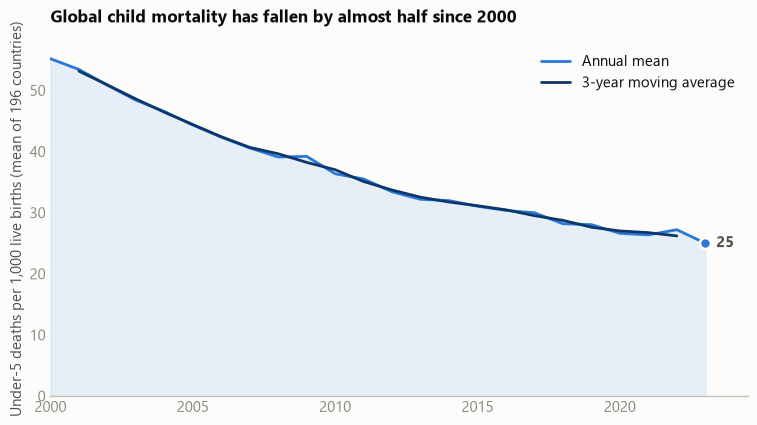

In [8]:
global_trend = (panel.groupby("year")["under5_mortality_per_1000"]
                .mean().rename("annual_mean").to_frame())
global_trend["ma3"] = global_trend["annual_mean"].rolling(3, center=True).mean()

first, last = global_trend["annual_mean"].iloc[0], global_trend["annual_mean"].iloc[-1]
decline_pct = (first - last) / first * 100
yearly_pace = (first - last) / (global_trend.index[-1] - global_trend.index[0])
print(f"Global (unweighted country) mean under-5 mortality: {first:.1f} (2000) -> {last:.1f} (2023)")
print(f"Decline: {first - last:.1f} deaths per 1,000 live births = {decline_pct:.1f}% in 23 years")
print(f"Average pace: {yearly_pace:.2f} fewer deaths per 1,000 each year")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.fill_between(global_trend.index, global_trend["annual_mean"], color="#2a78d6", alpha=0.10)
ax.plot(global_trend.index, global_trend["annual_mean"], color="#2a78d6", lw=2,
        solid_capstyle="round", label="Annual mean")
ax.plot(global_trend.index, global_trend["ma3"], color="#0d366b", lw=2,
        solid_capstyle="round", label="3-year moving average")
ax.scatter([global_trend.index[-1]], [last], s=64, color="#2a78d6",
           edgecolor=SURFACE, linewidth=2, zorder=5)
ax.annotate(f"{last:.0f}", (global_trend.index[-1], last),
            xytext=(8, 0), textcoords="offset points", va="center",
            color=INK2, fontweight="bold")
ax.set_xlim(2000, 2024.5); ax.set_ylim(0)
ax.set_title("Global child mortality has fallen by almost half since 2000",
             loc="left", fontweight="bold", color=INK, pad=14)
ax.set_ylabel("Under-5 deaths per 1,000 live births (mean of 196 countries)")
ax.legend(loc="upper right")
style_axis(ax)
fig.savefig(f"{FIG}/global_mortality_trend.png")
plt.show()

## 3. Comparative analysis — high-income vs low-income cohorts

Cohorts are the World Bank income classification (held fixed at the current classification for all years). The table tracks the two extreme cohorts; the chart in section 4 shows all four.

In [9]:
mort = inc_yr.pivot(index="year", columns="income_group",
                    values="under5_mortality_per_1000")[INCOME_ORDER]
cohort = pd.DataFrame({
    "Low income (deaths/1,000)": mort["Low income"],
    "High income (deaths/1,000)": mort["High income"],
})
cohort["Gap (absolute)"] = cohort.iloc[:, 0] - cohort.iloc[:, 1]
cohort["Ratio (low / high)"] = (cohort.iloc[:, 0] / cohort.iloc[:, 1]).round(1)
display(cohort.loc[[2000, 2005, 2010, 2015, 2020, 2023]].round(1))

for g in ["Low income", "High income"]:
    d0, d1 = mort[g].loc[2000], mort[g].loc[2023]
    print(f"{g}: {d0:.1f} -> {d1:.1f}  ({(d0-d1)/d0*100:.0f}% decline)")

spend = inc_yr.pivot(index="year", columns="income_group",
                     values="health_exp_per_capita_usd")[["Low income", "High income"]]
s = spend.loc[2022]
print(f"\nHealth spending per capita 2022: low income ${s['Low income']:.0f} vs high income ${s['High income']:.0f}"
      f"  ({s['High income']/s['Low income']:.0f}x more)")

,"Low income (deaths/1,000)","High income (deaths/1,000)",Gap (absolute),Ratio (low / high)
year,,,,
2000,151.2,11.4,139.8,13.2
2005,118.3,9.7,108.6,12.2
2010,96.5,8.3,88.2,11.7
2015,86.0,7.3,78.7,11.7
2020,70.7,6.6,64.1,10.7
2023,65.7,6.3,59.4,10.4


Low income: 151.2 -> 65.7  (57% decline)
High income: 11.4 -> 6.3  (45% decline)

Health spending per capita 2022: low income $43 vs high income $3424  (79x more)


**Cohort verdict.** Low-income countries improved *fastest in relative terms* (mortality down 57%, vs 45% for high income), yet the relative gap barely moved: a child born in a low-income country was ~13× more likely to die before age 5 than one in a high-income country in 2000 — and is still ~10× more likely today. High-income countries outspend low-income countries on health by ~79× per person ($3,424 vs $43 in 2022).

## 4. Visualizations
All figures are exported as PNG into `figures/`.

### 4.1 KPI summary cards

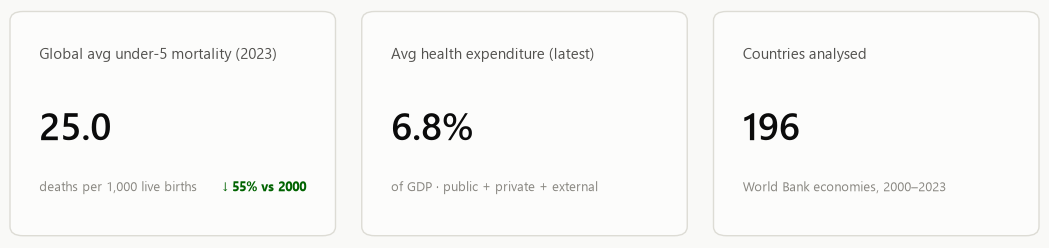

In [10]:
kpi_mort_2023 = latest["under5_mortality_per_1000"].mean()
kpi_mort_2000 = panel.loc[panel.year == 2000, "under5_mortality_per_1000"].mean()
kpi_delta_pct = (kpi_mort_2023 - kpi_mort_2000) / kpi_mort_2000 * 100
# health % of GDP: each country's most recent non-missing value
kpi_health = (panel.dropna(subset=["health_exp_pct_gdp"]).sort_values("year")
              .groupby("iso3c")["health_exp_pct_gdp"].last().mean())
kpi_n = latest.shape[0]

cards = [
    ("Global avg under-5 mortality (2023)", f"{kpi_mort_2023:.1f}",
     "deaths per 1,000 live births", f"\u2193 {abs(kpi_delta_pct):.0f}% vs 2000", GOOD_TEXT),
    ("Avg health expenditure (latest)", f"{kpi_health:.1f}%",
     "of GDP \u00b7 public + private + external", "", MUTED),
    ("Countries analysed", f"{kpi_n}",
     "World Bank economies, 2000\u20132023", "", MUTED),
]

fig = plt.figure(figsize=(10.5, 2.6))
fig.patch.set_facecolor(PAGE)
for i, (label, value, unit, delta, dcol) in enumerate(cards):
    ax = fig.add_axes([0.015 + i * 0.335, 0.06, 0.31, 0.88])
    ax.set_axis_off(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.add_patch(FancyBboxPatch((0.02, 0.03), 0.96, 0.94,
                 boxstyle="round,pad=0.02,rounding_size=0.04",
                 facecolor=SURFACE, edgecolor="#dddcd5", linewidth=1,
                 transform=ax.transAxes, clip_on=False))
    ax.text(0.09, 0.80, label, fontsize=10.5, color=INK2, va="center")
    ax.text(0.09, 0.47, value, fontsize=27, color=INK, fontweight="semibold", va="center")
    ax.text(0.09, 0.22, unit, fontsize=9.5, color=MUTED, va="center")
    if delta:
        ax.text(0.91, 0.22, delta, fontsize=9.5, color=dcol, va="center",
                ha="right", fontweight="bold")
fig.savefig(f"{FIG}/kpi_cards.png")
plt.show()

### 4.2 Child mortality trend over time, by income group

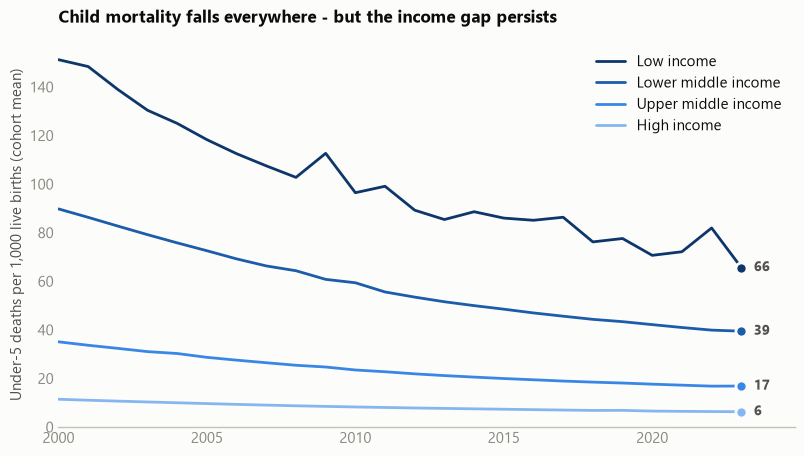

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 5))
for g in INCOME_ORDER:
    d = mort[g]
    ax.plot(d.index, d.values, color=INCOME_COLORS[g], lw=2,
            solid_capstyle="round", solid_joinstyle="round", label=g)
    ax.scatter([d.index[-1]], [d.values[-1]], s=64, color=INCOME_COLORS[g],
               edgecolor=SURFACE, linewidth=2, zorder=5)
    ax.annotate(f"{d.values[-1]:.0f}", (d.index[-1], d.values[-1]),
                xytext=(9, 0), textcoords="offset points", va="center",
                color=INK2, fontweight="bold", fontsize=10)
ax.set_xlim(2000, 2024.8); ax.set_ylim(0)
ax.set_title("Child mortality falls everywhere - but the income gap persists",
             loc="left", fontweight="bold", color=INK, pad=14)
ax.set_ylabel("Under-5 deaths per 1,000 live births (cohort mean)")
ax.legend(loc="upper right", title=None)
style_axis(ax)
fig.savefig(f"{FIG}/mortality_trend_by_income.png")
plt.show()

### 4.3 Choropleth — under-5 mortality by country (2023)

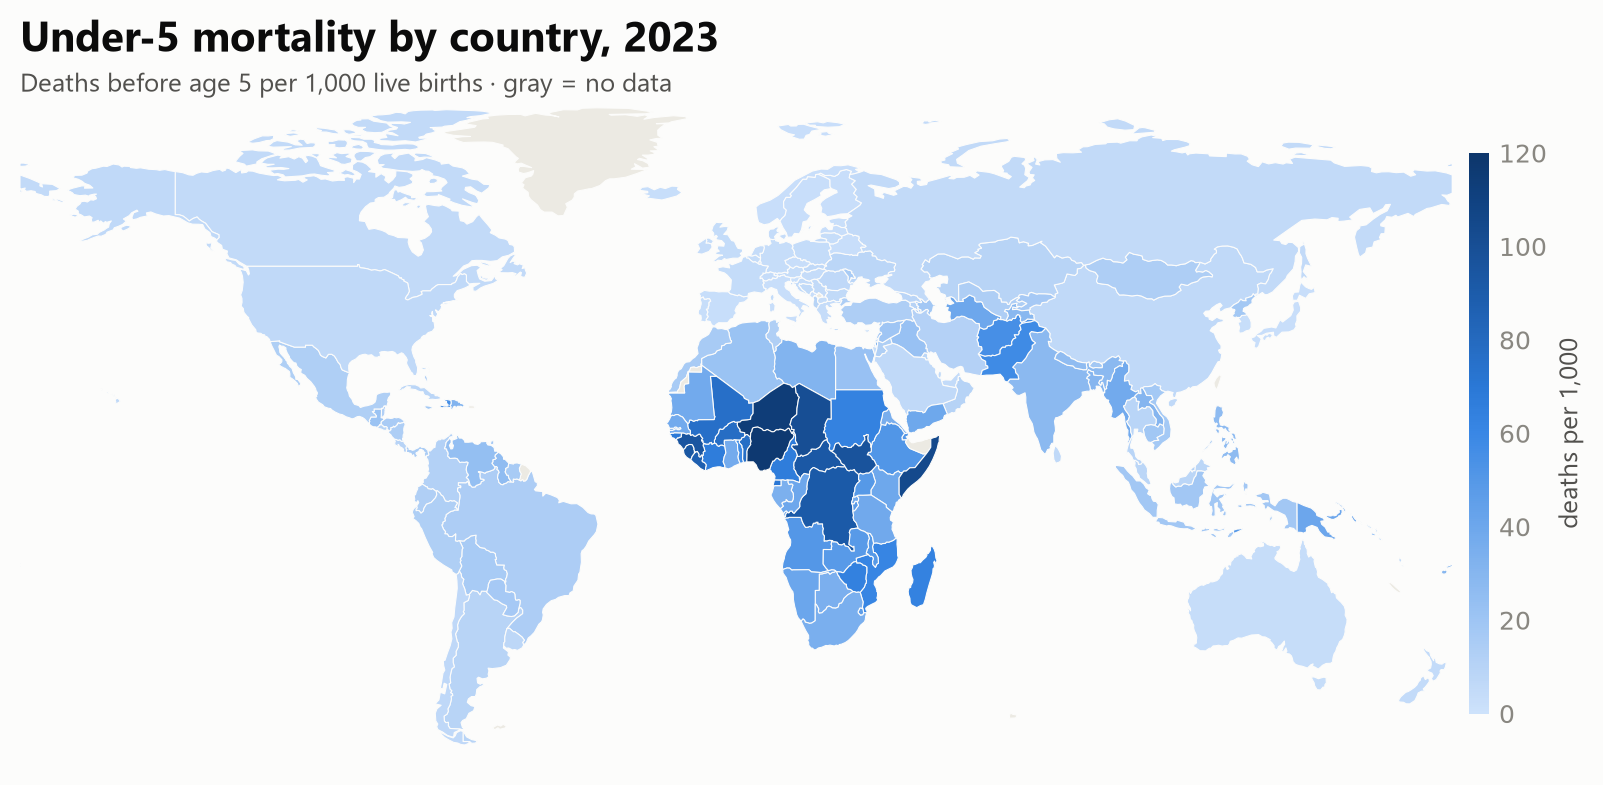

In [12]:
# The plotly choropleth is rendered by scripts/04_make_choropleth.py (same
# sequential-blue palette, ISO3-coded countries). It must run as a plain
# Python process: kaleido's Chrome-based PNG export deadlocks inside the
# Jupyter kernel's Windows event loop. If the PNG is missing, regenerate it
# with:  python scripts/04_make_choropleth.py
import subprocess, sys
from IPython.display import Image, display

map_png = f"{FIG}/mortality_choropleth.png"
if not os.path.exists(map_png):
    res = subprocess.run([sys.executable, "scripts/04_make_choropleth.py"],
                         capture_output=True, text=True, timeout=400)
    print(res.stdout.strip() or res.stderr.strip()[-400:])
display(Image(map_png, width=950))

### 4.4 GDP per capita (log) vs child mortality — bubble size = health spending, color = region

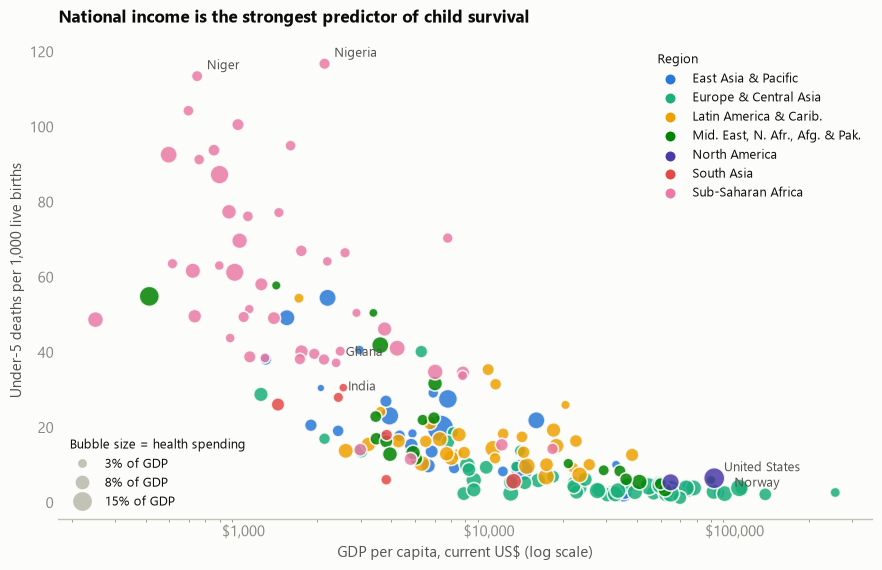

In [13]:
d = latest.dropna(subset=["gdp_per_capita_usd", "under5_mortality_per_1000",
                          "health_exp_pct_gdp"]).copy()

fig, ax = plt.subplots(figsize=(10.5, 6.2))
for region in REGION_ORDER:
    sub = d[d.region == region]
    ax.scatter(sub["gdp_per_capita_usd"], sub["under5_mortality_per_1000"],
               s=15 + sub["health_exp_pct_gdp"] * 13,
               color=REGION_COLORS[region], alpha=0.85,
               edgecolor=SURFACE, linewidth=1.2, label=REGION_SHORT[region])
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"${v:,.0f}" if v >= 1000 else f"${v:.0f}"))
ax.set_xlabel("GDP per capita, current US$ (log scale)")
ax.set_ylabel("Under-5 deaths per 1,000 live births")
ax.set_title("National income is the strongest predictor of child survival",
             loc="left", fontweight="bold", color=INK, pad=14)

# selective annotations (extremes + familiar reference points)
for name in ["Niger", "Nigeria", "Ghana", "India", "United States", "Norway"]:
    row = d[d.country.str.startswith(name)]
    if len(row):
        r = row.iloc[0]
        ax.annotate(name, (r["gdp_per_capita_usd"], r["under5_mortality_per_1000"]),
                    xytext=(7, 5), textcoords="offset points", fontsize=9, color=INK2)

leg1 = ax.legend(loc="upper right", fontsize=9, title="Region",
                 title_fontsize=9, alignment="left")
for h in leg1.legend_handles:
    h.set_sizes([70]); h.set_alpha(1)
ax.add_artist(leg1)
size_handles = [Line2D([], [], marker="o", linestyle="", markerfacecolor="#c3c2b7",
                       markeredgecolor=SURFACE, markersize=np.sqrt(15 + p * 13),
                       label=f"{p}% of GDP") for p in [3, 8, 15]]
ax.legend(handles=size_handles, loc="lower left", fontsize=9,
          title="Bubble size = health spending", title_fontsize=9, alignment="left")
style_axis(ax)
fig.savefig(f"{FIG}/gdp_vs_mortality_scatter.png")
plt.show()

### 4.5 Distribution of child mortality — histogram and box plot by region

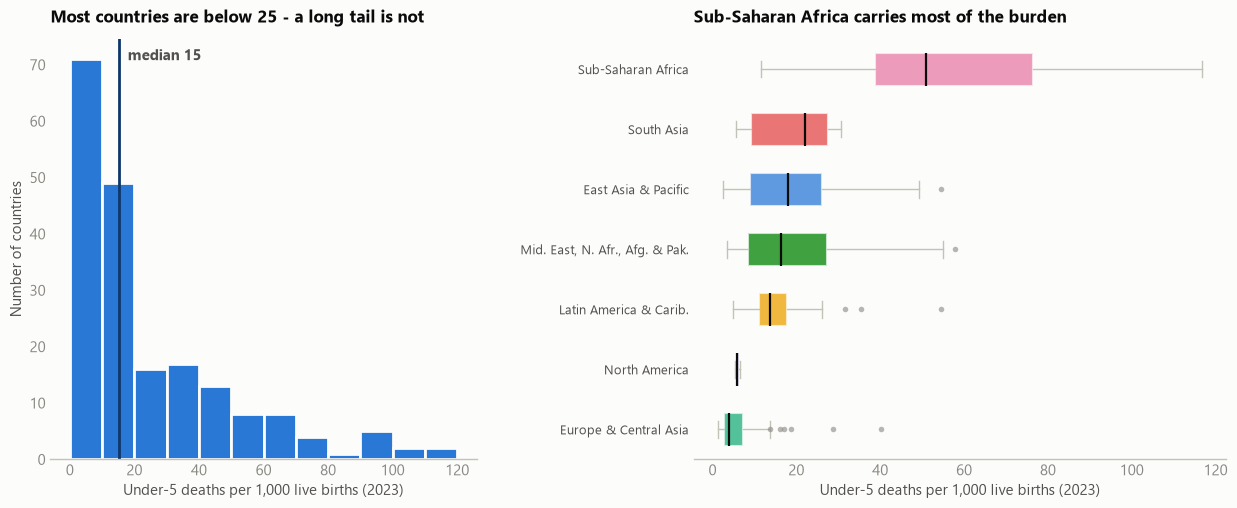

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.2),
                               gridspec_kw={"width_ratios": [1, 1.25]})

# histogram of the 2023 cross-section (single series -> no legend box)
vals = latest["under5_mortality_per_1000"]
ax1.hist(vals, bins=range(0, 130, 10), color="#2a78d6", edgecolor=SURFACE, linewidth=2)
med = vals.median()
ax1.axvline(med, color="#0d366b", lw=2)
ax1.annotate(f"median {med:.0f}", (med, ax1.get_ylim()[1] * 0.95),
             xytext=(6, 0), textcoords="offset points", color=INK2, fontweight="bold")
ax1.set_xlabel("Under-5 deaths per 1,000 live births (2023)")
ax1.set_ylabel("Number of countries")
ax1.set_title("Most countries are below 25 - a long tail is not",
              loc="left", fontweight="bold", color=INK, pad=12)
style_axis(ax1)

# box plot by region, ordered by median
order = (latest.groupby("region")["under5_mortality_per_1000"]
         .median().sort_values().index.tolist())
data = [latest.loc[latest.region == r, "under5_mortality_per_1000"].dropna() for r in order]
bp = ax2.boxplot(data, vert=False, patch_artist=True, widths=0.55,
                 medianprops=dict(color=INK, lw=1.6),
                 whiskerprops=dict(color=BASELINE), capprops=dict(color=BASELINE),
                 flierprops=dict(marker="o", markersize=4, markerfacecolor=MUTED,
                                 markeredgecolor="none", alpha=0.6))
for patch, r in zip(bp["boxes"], order):
    patch.set_facecolor(REGION_COLORS[r]); patch.set_alpha(0.75)
    patch.set_edgecolor(SURFACE); patch.set_linewidth(1.5)
ax2.set_yticklabels([REGION_SHORT[r] for r in order], fontsize=9.5, color=INK2)
ax2.set_xlabel("Under-5 deaths per 1,000 live births (2023)")
ax2.set_title("Sub-Saharan Africa carries most of the burden",
              loc="left", fontweight="bold", color=INK, pad=12)
ax2.grid(axis="x"); ax2.grid(axis="y", visible=False); ax2.tick_params(length=0)

fig.tight_layout(w_pad=3)
fig.savefig(f"{FIG}/mortality_distribution.png")
plt.show()

## 5. Key findings

1. **Income predicts survival.** Log GDP per capita correlates with under-5 mortality at **Pearson r = −0.77 / Spearman ρ = −0.87** (2023 cross-section, p < 10⁻³⁸) — the strongest relationship in the data. The scatter shows a near-linear downward slope on the log scale.
2. **Absolute health spending matters more than effort share.** Health expenditure *per capita* is almost as strongly negative (r = −0.76) as GDP; health expenditure *as % of GDP* is only weakly related (r = −0.22). Poor countries spending a large *share* of a small economy still spend very little per child.
3. **Everyone improved; the gap didn’t close.** Global mean under-5 mortality fell **55%** since 2000 (55.2 → 25.0), and low-income countries cut theirs by 57% — but a child in a low-income country remains **~10× more likely** to die before age 5 than in a high-income country.
4. **The burden is concentrated.** All 13 countries above 75 deaths per 1,000 in 2023 are in Sub-Saharan Africa; most high-income countries sit below 10.

Full interpretation, the "So what?" section and ethics note are in `report.md`.